# Market Simulator — интерактивная симуляция

Notebook для удобного запуска и анализа симуляций рынка.

**Содержание**
1. Настройка и импорты
2. Параметры симуляции
3. Построение рынка и обзор
4. Запуск симуляции
5. Визуализация результатов
6. Дополнительный анализ
7. Сравнение стратегий
8. Интерактивный симулятор

## 1. Настройка и импорты

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from market import (
    Market, Good, Seller,
    EpsilonGreedy, GradientAscent, PRICING_REGISTRY,
    FixedStock, BudgetFraction, STOCK_REGISTRY,
    build_market,
)
from market.visualization import plot_simulation

%matplotlib inline

print('Ценовые стратегии:', list(PRICING_REGISTRY))
print('Стратегии закупки:', list(STOCK_REGISTRY))

Ценовые стратегии: ['epsilon_greedy', 'gradient']
Стратегии закупки: ['fixed', 'budget_fraction']


## 2. Параметры симуляции

Меняйте значения ниже и перезапускайте последующие ячейки.

In [2]:
N_GOODS             = 2       # количество товаров (G1, G2, ...)
N_SELLERS           = 3       # количество продавцов (S1, S2, ...)
BUYERS_PER_DAY      = 1000    # размер потока покупателей
N_DAYS              = 90      # длительность симуляции (дней)
STRATEGY_NAME       = 'epsilon_greedy'   # 'epsilon_greedy' | 'gradient'
STOCK_STRATEGY_NAME = 'fixed'            # 'fixed' | 'budget_fraction'
SEED                = 42

## 3. Построение рынка и обзор

Здесь видно: для каждого товара его себестоимость, скрытые параметры спроса (`value`, `lam`),
монопольную оптимальную цену и список продавцов.

In [3]:
market = build_market(N_GOODS, N_SELLERS, BUYERS_PER_DAY, SEED)

print(f"Рынок: {len(market.goods)} товара(ов), {len(market.sellers)} продавцов, "
      f"{market.buyers_per_day} покупателей/день\n")

print(f"{'Товар':<22} {'cost':>7} {'value':>7} {'lam':>6} {'opt':>7}")
print('-' * 56)
for good_id, g in market.goods.items():
    print(f"{g.name:<22} {g.cost:>7.2f} {g.value:>7.2f} {g.lam:>6.3f} "
          f"{g.monopoly_optimal_price():>7.2f}")

print('\nПродавцы: товары приобретаются динамически через стратегию закупки.')
for s in market.sellers:
    print(f"  {s.name}: бюджет={s.budget:.0f}")

Рынок: 2 товара(ов), 3 продавцов, 1000 покупателей/день

Товар                     cost   value    lam     opt
--------------------------------------------------------
Bread                    12.00   43.93  0.144   37.24
Milk                     18.00   68.18  0.170   57.90

Продавцы: товары приобретаются динамически через стратегию закупки.
  S1: бюджет=10000
  S2: бюджет=10000
  S3: бюджет=10000


## 5. Запуск симуляции

`verbose=False` отключает периодический лог по дням. Поставьте `True`, если хотите
видеть промежуточный вывод (~10 точек на симуляцию).

In [4]:
pricing_strategy = PRICING_REGISTRY[STRATEGY_NAME]
stock_strategy = STOCK_REGISTRY[STOCK_STRATEGY_NAME]

market.run(n_days=N_DAYS, pricing_strategy=pricing_strategy, stock_strategy=stock_strategy, verbose=False)

print(f"Симуляция завершена ({market.day} дней, "
      f"цена={STRATEGY_NAME}, закупка={STOCK_STRATEGY_NAME}).\n")
print('Итоговая накопленная прибыль:')
for s in sorted(market.sellers, key=lambda x: -x.total_profit()):
    stock_info = ', '.join(f'{g}:{s.stock_level(g)}' for g in s.goods)
    print(f"  {s.name:<8}  прибыль={s.total_profit():>10.1f}  бюджет={s.budget:>10.1f}"
          f"  сток=[{stock_info}]")

Симуляция завершена (90 дней, цена=epsilon_greedy, закупка=fixed).

Итоговая накопленная прибыль:
  S2        прибыль=  680772.7  бюджет=  420772.7  сток=[d40c7a41-25d2-4371-a859-8c990afa845a:0, 53a90a9f-6b0f-4d49-ae32-035bf7484528:0]
  S1        прибыль=  669330.3  бюджет=  409330.3  сток=[d40c7a41-25d2-4371-a859-8c990afa845a:0, 53a90a9f-6b0f-4d49-ae32-035bf7484528:0]
  S3        прибыль=  667180.4  бюджет=  407180.4  сток=[d40c7a41-25d2-4371-a859-8c990afa845a:41, 53a90a9f-6b0f-4d49-ae32-035bf7484528:0]


## 6. Визуализация результатов

`plot_simulation` сохраняет PNG (бэкенд `Agg`); ниже отображаем её прямо в notebook.


Plot saved → market_simulation.png


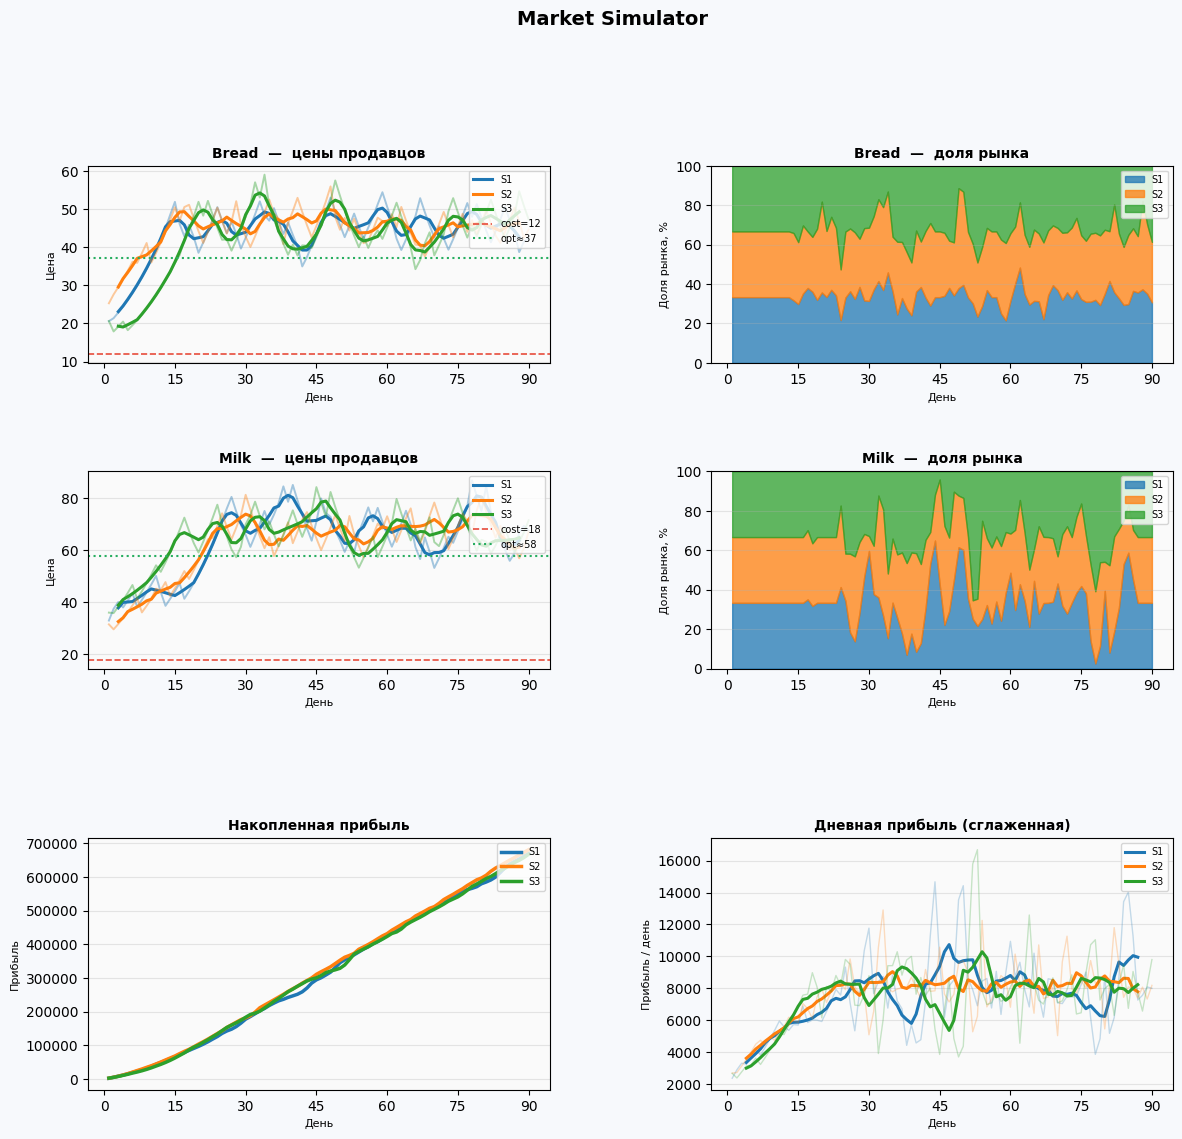

In [5]:
plot_path = 'market_simulation.png'
plot_simulation(market, save_path=plot_path)
# display(Image(filename=plot_path))

## 7. Дополнительный анализ

### 7.1 Накопленная прибыль (inline)

Гибкий inline-график в стиле notebook (без сохранения в файл).

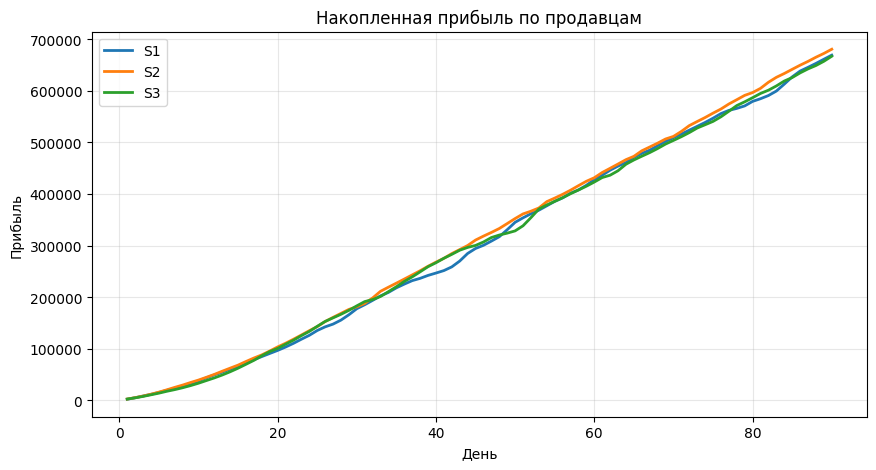

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
days = np.arange(1, market.day + 1)
for s in market.sellers:
    ax.plot(days, np.cumsum(s.profit_series(market.day)), label=s.name, linewidth=2)
ax.set_title('Накопленная прибыль по продавцам')
ax.set_xlabel('День')
ax.set_ylabel('Прибыль')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 7.2 Сходимость цены к монопольному оптимуму

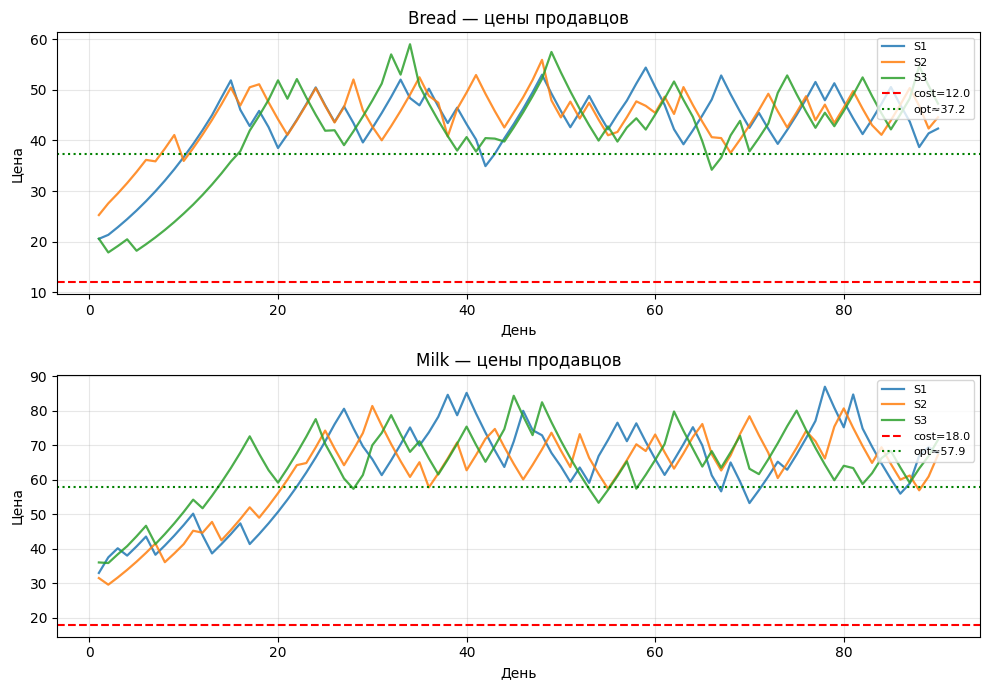

In [7]:
good_ids = market.goods.ids()
fig, axes = plt.subplots(len(good_ids), 1, figsize=(10, 3.5 * len(good_ids)),
                         squeeze=False)

for row, good_id in enumerate(good_ids):
    ax   = axes[row, 0]
    good = market.goods[good_id]
    for s in market.sellers:
        if good_id not in s.goods:
            continue
        prices = s.good_metrics[good_id].prices
        s_days = np.arange(s.start_day, s.start_day + len(prices))
        ax.plot(s_days, prices, label=s.name, alpha=0.85, linewidth=1.6)
    ax.axhline(good.cost, color='red', linestyle='--', label=f'cost={good.cost:.1f}')
    ax.axhline(good.monopoly_optimal_price(), color='green', linestyle=':',
               label=f'opt≈{good.monopoly_optimal_price():.1f}')
    ax.set_title(f'{good.name} — цены продавцов')
    ax.set_xlabel('День')
    ax.set_ylabel('Цена')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 Финальная цена vs. оптимум

In [8]:
rows = []
for good_id, good in market.goods.items():
    opt = good.monopoly_optimal_price()
    for s in market.sellers:
        if good_id not in s.goods or not s.good_metrics[good_id].prices:
            continue
        last  = s.good_metrics[good_id].prices[-1]
        delta = (last - opt) / opt * 100
        rows.append((good.name, s.name, good.cost, last, opt, delta))

print(f"{'good':<22} {'seller':<8} {'cost':>7} {'final':>7} {'opt':>7} {'Δ%':>7}")
print('-' * 65)
for gname, sname, cost, last, opt, delta in rows:
    print(f"{gname:<22} {sname:<8} {cost:>7.2f} {last:>7.2f} {opt:>7.2f} {delta:>+6.1f}%")

good                   seller      cost   final     opt      Δ%
-----------------------------------------------------------------
Bread                  S1         12.00   42.34   37.24  +13.7%
Bread                  S2         12.00   44.58   37.24  +19.7%
Bread                  S3         12.00   47.26   37.24  +26.9%
Milk                   S1         18.00   67.65   57.90  +16.8%
Milk                   S2         18.00   67.25   57.90  +16.1%
Milk                   S3         18.00   71.58   57.90  +23.6%


### 7.4 Уровень стока и бюджет по продавцам

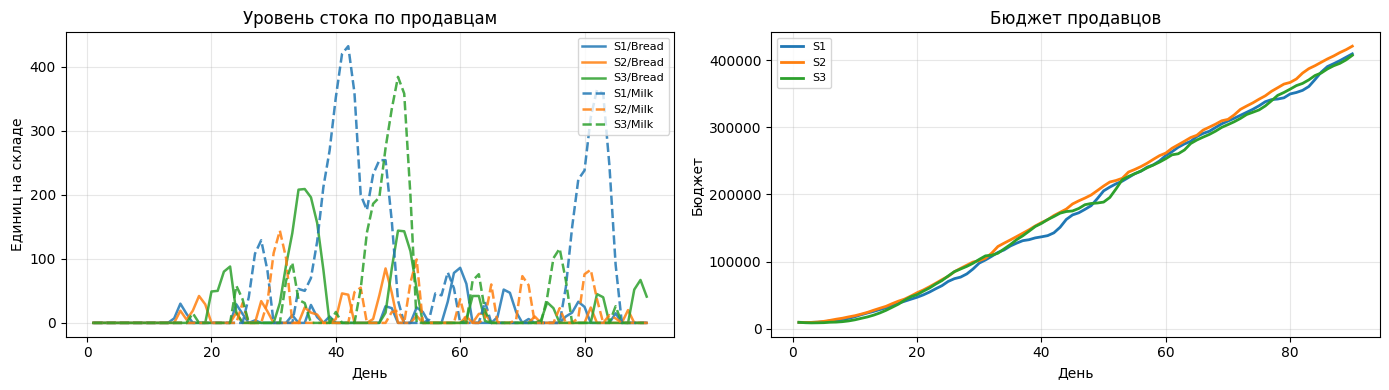

In [9]:
good_ids = market.goods.ids()
palette  = plt.cm.tab10.colors
sc       = {s.name: palette[i % 10] for i, s in enumerate(market.sellers)}
linestyles = ['-', '--', ':', '-.']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── уровень стока ──────────────────────────────────────────────
ax = axes[0]
for gi, good_id in enumerate(good_ids):
    good = market.goods[good_id]
    ls   = linestyles[gi % len(linestyles)]
    for s in market.sellers:
        sh = s.good_metrics[good_id].stock if good_id in s.good_metrics else []
        if not sh:
            continue
        sd = np.arange(s.start_day, s.start_day + len(sh))
        ax.plot(sd, sh, color=sc[s.name], ls=ls, lw=1.8,
                label=f'{s.name}/{good.name}', alpha=0.85)
ax.set_title('Уровень стока по продавцам')
ax.set_xlabel('День')
ax.set_ylabel('Единиц на складе')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)

# ── бюджет ─────────────────────────────────────────────────────
ax2 = axes[1]
for s in market.sellers:
    if not s.seller_metrics.budget:
        continue
    sd = np.arange(s.start_day, s.start_day + len(s.seller_metrics.budget))
    ax2.plot(sd, s.seller_metrics.budget, color=sc[s.name], lw=2, label=s.name)
ax2.set_title('Бюджет продавцов')
ax2.set_xlabel('День')
ax2.set_ylabel('Бюджет')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Сравнение стратегий

Прогон одной и той же конфигурации рынка под каждой стратегией из реестра.
Сравниваем суммарную прибыль рынка.

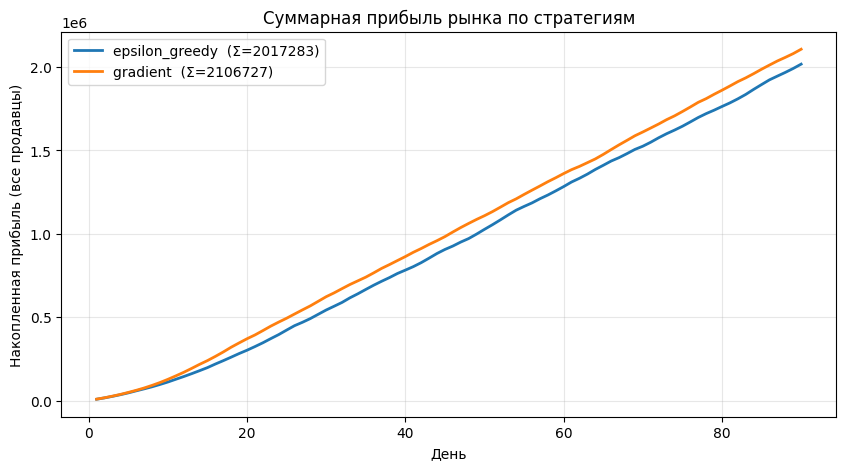

In [10]:
def run_with(strategy_name: str, stock_strategy_name: str = STOCK_STRATEGY_NAME,
             n_days: int = N_DAYS) -> Market:
    m = build_market(N_GOODS, N_SELLERS, BUYERS_PER_DAY, SEED)
    m.run(
        n_days=n_days,
        pricing_strategy=PRICING_REGISTRY[strategy_name],
        stock_strategy=STOCK_REGISTRY[stock_strategy_name],
        verbose=False,
    )
    return m

results = {name: run_with(name) for name in PRICING_REGISTRY}

fig, ax = plt.subplots(figsize=(10, 5))
for name, m in results.items():
    total = np.zeros(m.day)
    for s in m.sellers:
        total += s.profit_series(m.day)
    ax.plot(np.arange(1, m.day + 1), np.cumsum(total),
            label=f"{name}  (Σ={total.sum():.0f})", linewidth=2)
ax.set_title('Суммарная прибыль рынка по стратегиям')
ax.set_xlabel('День')
ax.set_ylabel('Накопленная прибыль (все продавцы)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 9. Интерактивный симулятор

Пошаговое управление симуляцией:

**Инициализация** — задай параметры рынка и нажми «Инициализировать».

**Пошаговое исполнение** (один день = три фазы):
- **1 · Закупка** — продавцы закупают товар по выбранной стратегии
- **2 · Выставить цены** — стратегия ценообразования обновляет цены
- **3 · День продаж** — покупатели делают выборы, история обновляется

**По дням** — «+1 день» или «▶ Запустить N дней» пропускают отдельные фазы.

Все графики обновляются после каждого действия.


In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np, sys
from pathlib import Path

_root = str(Path.cwd())
if _root not in sys.path:
    sys.path.insert(0, _root)

from market import build_market, PRICING_REGISTRY, STOCK_REGISTRY

# ── state: idle | ready | purchased | priced ──────────────────────
_st = {'market': None, 'pricing_strategy': None, 'stock_strategy': None, 'phase': 'idle'}

# ── utilities ─────────────────────────────────────────────────────
def _smooth(arr, x, w=5):
    arr = np.asarray(arr, dtype=float)
    x   = np.asarray(x)
    if len(arr) < w:
        return x, arr
    sm = np.convolve(arr, np.ones(w) / w, mode='valid')
    return x[(w - 1) // 2: (w - 1) // 2 + len(sm)], sm

def _seller_colors(m):
    return {s.name: plt.cm.tab10.colors[i % 10] for i, s in enumerate(m.sellers)}

def _style_ax(ax, title, ylabel):
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('День', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.25)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

def _show(out, fig):
    with out:
        clear_output(wait=True)
        display(fig)
    plt.close(fig)

# ── tab drawing ───────────────────────────────────────────────────
def _draw_sellers(out, m):
    sc   = _seller_colors(m)
    n    = m.day
    days = np.arange(1, n + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor('#F7F9FC')
    for ax in (ax1, ax2):
        ax.set_facecolor('#FAFAFA')
    for s in m.sellers:
        bud = s.seller_metrics.budget
        if bud:
            bd = np.arange(s.start_day, s.start_day + len(bud))
            ax1.plot(bd, bud, color=sc[s.name], lw=2, label=s.name)
        if s.goods and n > 0:
            ax2.plot(days, np.cumsum(s.profit_series(n)), color=sc[s.name], lw=2, label=s.name)
    _style_ax(ax1, 'Бюджет продавцов', 'Бюджет')
    _style_ax(ax2, 'Накопленная прибыль', 'Прибыль')
    plt.tight_layout()
    _show(out, fig)

def _draw_prices(out, m):
    sc       = _seller_colors(m)
    good_ids = m.goods.ids()
    fig, axes = plt.subplots(1, len(good_ids), figsize=(6 * len(good_ids), 4), squeeze=False)
    fig.patch.set_facecolor('#F7F9FC')
    for col, good_id in enumerate(good_ids):
        ax       = axes[0, col]; ax.set_facecolor('#FAFAFA')
        good     = m.goods[good_id]
        carriers = [s for s in m.sellers if good_id in s.goods]
        for s in carriers:
            ph = s.good_metrics[good_id].prices
            if not ph:
                continue
            sd = np.arange(s.start_day, s.start_day + len(ph))
            ax.plot(sd, ph, color=sc[s.name], alpha=0.3, lw=1)
            sd_sm, sm = _smooth(ph, sd)
            ax.plot(sd_sm, sm, color=sc[s.name], lw=2, label=s.name)
        opt = good.monopoly_optimal_price()
        ax.axhline(good.cost, color='#E74C3C', ls='--', lw=1.2, label=f'cost={good.cost:.0f}')
        ax.axhline(opt,       color='#27AE60', ls=':',  lw=1.5, label=f'opt≈{opt:.0f}')
        _style_ax(ax, f'{good.name} — цены', 'Цена')
    plt.tight_layout()
    _show(out, fig)

def _draw_sales(out, m):
    sc       = _seller_colors(m)
    good_ids = m.goods.ids()
    n_g      = len(good_ids)
    n        = m.day
    days     = np.arange(1, n + 1)
    fig, axes = plt.subplots(1, n_g + 1, figsize=(6 * (n_g + 1), 4), squeeze=False)
    fig.patch.set_facecolor('#F7F9FC')
    for col, good_id in enumerate(good_ids):
        ax       = axes[0, col]; ax.set_facecolor('#FAFAFA')
        good     = m.goods[good_id]
        carriers = [s for s in m.sellers if good_id in s.goods]
        if carriers and n > 0:
            sm_arr = np.array([s.sales_series(good_id, n) for s in carriers])
            tots   = sm_arr.sum(axis=0)
            shares = sm_arr / np.where(tots == 0, 1, tots) * 100
            bot    = np.zeros(n)
            for idx, s in enumerate(carriers):
                ax.fill_between(days, bot, bot + shares[idx],
                                color=sc[s.name], alpha=0.75, label=s.name)
                bot += shares[idx]
        ax.set_ylim(0, 100)
        _style_ax(ax, f'{good.name} — доля рынка', '%')
    ax_dp = axes[0, n_g]; ax_dp.set_facecolor('#FAFAFA')
    if n > 0:
        for s in m.sellers:
            if s.goods:
                daily = s.profit_series(n)
                ax_dp.plot(days, daily, color=sc[s.name], alpha=0.2, lw=1)
                d_sm, sm_d = _smooth(daily, days, w=7)
                ax_dp.plot(d_sm, sm_d, color=sc[s.name], lw=2, label=s.name)
    _style_ax(ax_dp, 'Дневная прибыль (сглаж.)', 'Прибыль/день')
    plt.tight_layout()
    _show(out, fig)

def _draw_stocks(out, m):
    sc       = _seller_colors(m)
    good_ids = m.goods.ids()
    fig, axes = plt.subplots(1, len(good_ids), figsize=(6 * len(good_ids), 4), squeeze=False)
    fig.patch.set_facecolor('#F7F9FC')
    for col, good_id in enumerate(good_ids):
        ax   = axes[0, col]; ax.set_facecolor('#FAFAFA')
        good = m.goods[good_id]
        for s in m.sellers:
            sh = s.good_metrics[good_id].stock if good_id in s.good_metrics else []
            if not sh:
                continue
            sd = np.arange(s.start_day, s.start_day + len(sh))
            ax.plot(sd, sh, color=sc[s.name], lw=1.8, label=s.name, alpha=0.85)
        _style_ax(ax, f'{good.name} — уровень стока', 'Единиц')
    plt.tight_layout()
    _show(out, fig)

# ── metrics table ─────────────────────────────────────────────────
def _metrics_html(m) -> str:
    if m.day == 0:
        return '<i style="color:#888">Симуляция ещё не запущена — нажмите «Закупка» или «+1 день»</i>'
    th = '<th style="padding:3px 10px;border-bottom:1px solid #ccc;text-align:left">'
    rows = []
    for s in sorted(m.sellers, key=lambda x: -x.total_profit()):
        p_day = sum((s.good_metrics[g].profit[-1] if s.good_metrics[g].profit else 0) for g in s.goods)
        s_day = sum((s.good_metrics[g].sales[-1]  if s.good_metrics[g].sales  else 0) for g in s.goods)
        prices_str = '  '.join(f'{m.goods[g].name}:{s.prices[g]:.1f}' for g in s.goods) if s.goods else '—'
        stock_str  = '  '.join(f'{m.goods[g].name}:{s.stock_level(g)}' for g in s.goods) if s.goods else '—'
        rows.append(
            f'<tr><td><b>{s.name}</b></td>'
            f'<td><b>{s.budget:,.0f}</b></td>'
            f'<td>{s.total_profit():,.0f}</td>'
            f'<td>{p_day:,.0f}</td><td>{s_day}</td>'
            f'<td style="font-family:monospace;font-size:11px">{prices_str}</td>'
            f'<td style="font-family:monospace;font-size:11px">{stock_str}</td></tr>'
        )
    return (
        f'<table style="border-collapse:collapse;font-size:12px">'
        f'<thead><tr style="background:#f0f0f0">'
        f'{th}Продавец</th>{th}Бюджет</th>{th}Прибыль Σ</th>'
        f'{th}Сегодня</th>{th}Продаж</th>{th}Цены</th>{th}Сток</th></tr></thead>'
        f'<tbody>{"".join(rows)}</tbody></table>'
    )

# ── phase indicator ───────────────────────────────────────────────
_PHASE_NEXT = {
    'ready':     'следующий шаг: закупка',
    'purchased': 'следующий шаг: цены',
    'priced':    'следующий шаг: продажи',
}

def _update_phase_label():
    m     = _st['market']
    phase = _st['phase']
    if phase == 'idle' or m is None:
        phase_label.value = ''
        return
    phase_label.value = (
        f'<span style="font-family:monospace;background:#f0f4ff;'
        f'padding:3px 8px;border-radius:4px;font-size:12px">'
        f'День {m.day} завершён &nbsp;·&nbsp; {_PHASE_NEXT[phase]}</span>'
    )

# ── refresh ───────────────────────────────────────────────────────
def _refresh_all():
    m = _st['market']
    if m is None:
        return
    with out_metrics:
        clear_output(wait=True)
        display(HTML(_metrics_html(m)))
    if m.day > 0:
        _draw_sellers(out_tab_sellers, m)
        _draw_prices(out_tab_prices, m)
        _draw_sales(out_tab_sales, m)
        _draw_stocks(out_tab_stocks, m)

# ── actions ───────────────────────────────────────────────────────
def _do_purchase():
    _st['market']._purchase_stock(_st['stock_strategy'])
    _st['phase'] = 'purchased'

def _do_prices():
    _st['market']._update_prices(_st['pricing_strategy'])
    _st['phase'] = 'priced'

def _do_simulate():
    _st['market']._simulate_day()
    _st['phase'] = 'ready'

def _do_full_day():
    _do_purchase(); _do_prices(); _do_simulate()

# ── button state ──────────────────────────────────────────────────
def _update_controls():
    phase = _st['phase']
    btn_purchase.disabled = phase != 'ready'
    btn_prices.disabled   = phase != 'purchased'
    btn_simulate.disabled = phase != 'priced'
    btn_day1.disabled     = phase != 'ready'
    btn_run.disabled      = phase != 'ready'
    btn_reset.disabled    = phase == 'idle'
    _update_phase_label()

# ── callbacks ─────────────────────────────────────────────────────
def _on_init(_b):
    m = build_market(w_goods.value, w_sellers.value, w_buyers.value, w_seed.value)
    _st.update(
        market=m,
        pricing_strategy=PRICING_REGISTRY[w_strat.value],
        stock_strategy=STOCK_REGISTRY[w_stock_strat.value],
        phase='ready',
    )
    with out_setup:
        clear_output(wait=True)
        lines = [
            f'<b>{g.name}</b>: cost={g.cost:.1f} | value={g.value:.1f} | '
            f'lam={g.lam:.3f} | opt≈{g.monopoly_optimal_price():.1f}'
            for g in m.goods.values()
        ]
        display(HTML('<br>'.join(lines)))
    for o in (out_metrics, out_tab_sellers, out_tab_prices, out_tab_sales, out_tab_stocks):
        with o: clear_output(wait=True)
    _update_controls()
    _refresh_all()

def _on_purchase(_b): _do_purchase(); _update_controls(); _refresh_all()
def _on_prices(_b):   _do_prices();   _update_controls(); _refresh_all()
def _on_simulate(_b): _do_simulate(); _update_controls(); _refresh_all()
def _on_day1(_b):     _do_full_day(); _update_controls(); _refresh_all()

def _on_run(_b):
    for _ in range(w_run_n.value):
        _do_full_day()
    _update_controls(); _refresh_all()

def _on_reset(_b):
    _st.update(market=None, pricing_strategy=None, stock_strategy=None, phase='idle')
    for o in (out_setup, out_metrics, out_tab_sellers, out_tab_prices, out_tab_sales, out_tab_stocks):
        with o: clear_output(wait=True)
    _update_controls()

# ── widget definitions ────────────────────────────────────────────
_W = widgets.Layout
_S = lambda w: {'description_width': w}

w_goods       = widgets.BoundedIntText(value=2, min=1, max=20,         description='Товаров:',     style=_S('75px'), layout=_W(width='155px'))
w_sellers     = widgets.BoundedIntText(value=3, min=1, max=10,         description='Продавцов:',   style=_S('75px'), layout=_W(width='165px'))
w_buyers      = widgets.BoundedIntText(value=1000, min=100, max=20000, step=100,
                                        description='Покупателей:',    style=_S('85px'), layout=_W(width='185px'))
w_seed        = widgets.BoundedIntText(value=42, min=0, max=99999,     description='Сид:',         style=_S('35px'), layout=_W(width='130px'))
w_strat       = widgets.Dropdown(options=list(PRICING_REGISTRY),       description='Цены:',        style=_S('45px'), layout=_W(width='200px'))
w_stock_strat = widgets.Dropdown(options=list(STOCK_REGISTRY),         description='Закупка:',     style=_S('60px'), layout=_W(width='215px'))
btn_init      = widgets.Button(description='⚙ Инициализировать', button_style='primary', layout=_W(width='185px'))
out_setup     = widgets.Output()

phase_label   = widgets.HTML('')
btn_purchase  = widgets.Button(description='1 · Закупка',        button_style='info',    disabled=True, layout=_W(width='130px'))
btn_prices    = widgets.Button(description='2 · Выставить цены', button_style='info',    disabled=True, layout=_W(width='155px'))
btn_simulate  = widgets.Button(description='3 · День продаж',    button_style='info',    disabled=True, layout=_W(width='130px'))
btn_day1      = widgets.Button(description='+1 день',            button_style='success', disabled=True, layout=_W(width='100px'))
w_run_n       = widgets.BoundedIntText(value=10, min=1, max=9999, description='Дней:', style=_S('42px'), layout=_W(width='120px'))
btn_run       = widgets.Button(description='▶ Запустить',        button_style='success', disabled=True, layout=_W(width='120px'))
btn_reset     = widgets.Button(description='↺ Сброс',            button_style='danger',  disabled=True, layout=_W(width='95px'))

btn_init.on_click(_on_init)
btn_purchase.on_click(_on_purchase)
btn_prices.on_click(_on_prices)
btn_simulate.on_click(_on_simulate)
btn_day1.on_click(_on_day1)
btn_run.on_click(_on_run)
btn_reset.on_click(_on_reset)

out_metrics     = widgets.Output()
out_tab_sellers = widgets.Output()
out_tab_prices  = widgets.Output()
out_tab_sales   = widgets.Output()
out_tab_stocks  = widgets.Output()

tabs = widgets.Tab(children=[out_tab_sellers, out_tab_prices, out_tab_sales, out_tab_stocks])
for i, title in enumerate(['Продавцы', 'Цены', 'Продажи', 'Стоки']):
    tabs.set_title(i, title)

sep = lambda: widgets.HTML('<hr style="margin:6px 0;border-color:#ddd">')

display(widgets.VBox([
    widgets.HTML('<h3 style="margin:6px 0">⚙ Инициализация</h3>'),
    widgets.HBox([w_goods, w_sellers, w_buyers, w_seed]),
    widgets.HBox([w_strat, w_stock_strat, btn_init]),
    out_setup,
    sep(),
    widgets.HTML('<h3 style="margin:6px 0">▶ Управление</h3>'),
    phase_label,
    widgets.HTML('<div style="color:#666;font-size:11px;margin:4px 0 2px">Пошагово:</div>'),
    widgets.HBox([btn_purchase, btn_prices, btn_simulate]),
    widgets.HTML('<div style="color:#666;font-size:11px;margin:6px 0 2px">По дням:</div>'),
    widgets.HBox([btn_day1, w_run_n, btn_run, btn_reset]),
    sep(),
    widgets.HTML('<h3 style="margin:6px 0">📊 Показатели</h3>'),
    out_metrics,
    tabs,
]))